# Simple Linear Regression Model for Bakery Sales Prediction

This notebook implements a basic linear regression model to predict bakery sales (`umsatz`) based on available features.

## Model Equation
We'll start with a simple linear model:
```
umsatz = β₀ + β₁ × Temperatur + β₂ × Warengruppe + ε
```

Where:
- β₀ is the intercept
- β₁, β₂ are the coefficients for temperature and product group
- ε is the error term

In [2]:
# Install required packages
%pip install scikit-learn seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 51.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.9/35.9 MB 85.7 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [seaborn]m4/5 [seaborn]earn]
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [4]:
# Load the datasets
print("Loading datasets...")
train_data = pd.read_csv('../0_DataPreparation/data/train_data.csv')
val_data = pd.read_csv('../0_DataPreparation/data/val_data.csv')
test_data = pd.read_csv('../0_DataPreparation/data/test_data.csv')

# Convert date columns to datetime
for df in [train_data, val_data, test_data]:
    df['date'] = pd.to_datetime(df['date'])

print(f"Training data: {train_data.shape}")
print(f"Validation data: {val_data.shape}")
print(f"Test data: {test_data.shape}")

# Check for missing values in training data
print("\nMissing values in training data:")
print(train_data.isnull().sum())

# Display basic statistics
print("\nTraining data statistics:")
print(train_data.describe())

Loading datasets...
Training data: (7493, 9)
Validation data: (1841, 9)
Test data: (1830, 9)

Missing values in training data:
id                        0
date                      0
Warengruppe               0
umsatz                    0
KielerWoche            7315
Bewoelkung                6
Temperatur                6
Windgeschwindigkeit       6
Wettercode             2094
dtype: int64

Training data statistics:
                 id                           date  Warengruppe       umsatz  \
count  7.493000e+03                           7493  7493.000000  7493.000000   
mean   1.509190e+06  2015-07-14 22:00:39.396770304     3.087415   209.338996   
min    1.307011e+06            2013-07-01 00:00:00     1.000000    12.937383   
25%    1.407094e+06            2014-07-09 00:00:00     2.000000    96.774910   
50%    1.507172e+06            2015-07-17 00:00:00     3.000000   162.622977   
75%    1.607233e+06            2016-07-23 00:00:00     4.000000   283.910218   
max    1.707315e+06  

## Data Preprocessing

Before building the model, we need to prepare our features and handle any missing values.

In [5]:
# Data preprocessing
def preprocess_data(df):
    """Preprocess data for linear regression"""
    df_processed = df.copy()
    
    # Fill missing values with appropriate strategies
    # For KielerWoche, fill NaN with 0 (no Kieler Woche)
    df_processed['KielerWoche'] = df_processed['KielerWoche'].fillna(0)
    
    # For weather features, use forward fill then backward fill
    weather_cols = ['Bewoelkung', 'Temperatur', 'Windgeschwindigkeit', 'Wettercode']
    for col in weather_cols:
        df_processed[col] = df_processed[col].fillna(method='ffill').fillna(method='bfill')
    
    # Create additional time-based features
    df_processed['year'] = df_processed['date'].dt.year
    df_processed['month'] = df_processed['date'].dt.month
    df_processed['day'] = df_processed['date'].dt.day
    df_processed['dayofweek'] = df_processed['date'].dt.dayofweek  # Monday=0, Sunday=6
    df_processed['is_weekend'] = (df_processed['dayofweek'] >= 5).astype(int)
    
    return df_processed

# Apply preprocessing
train_processed = preprocess_data(train_data)
val_processed = preprocess_data(val_data)
test_processed = preprocess_data(test_data)

print("✅ Data preprocessing completed")
print(f"Training data shape after preprocessing: {train_processed.shape}")

# Check if there are still any missing values
print("\nMissing values after preprocessing:")
print(train_processed.isnull().sum())

✅ Data preprocessing completed
Training data shape after preprocessing: (7493, 14)

Missing values after preprocessing:
id                     0
date                   0
Warengruppe            0
umsatz                 0
KielerWoche            0
Bewoelkung             0
Temperatur             0
Windgeschwindigkeit    0
Wettercode             0
year                   0
month                  0
day                    0
dayofweek              0
is_weekend             0
dtype: int64


## Simple Linear Regression Model

We'll implement our simple linear model equation:
**umsatz = β₀ + β₁ × Temperatur + β₂ × Warengruppe + β₃ × is_weekend + ε**

Starting with basic features that are likely to influence sales.

In [6]:
# Define features for the simple linear model
feature_columns = ['Temperatur', 'Warengruppe', 'is_weekend', 'month']

# Prepare training data
X_train = train_processed[feature_columns]
y_train = train_processed['umsatz']

# Prepare validation data
X_val = val_processed[feature_columns]
y_val = val_processed['umsatz']

# Prepare test data
X_test = test_processed[feature_columns]

print("Feature columns:", feature_columns)
print(f"Training features shape: {X_train.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Validation features shape: {X_val.shape}")
print(f"Test features shape: {X_test.shape}")

# Display feature statistics
print("\nTraining features statistics:")
print(X_train.describe())

Feature columns: ['Temperatur', 'Warengruppe', 'is_weekend', 'month']
Training features shape: (7493, 4)
Training target shape: (7493,)
Validation features shape: (1841, 4)
Test features shape: (1830, 4)

Training features statistics:
        Temperatur  Warengruppe   is_weekend        month
count  7493.000000  7493.000000  7493.000000  7493.000000
mean     12.078105     3.087415     0.285867     6.653677
std       7.024442     1.490034     0.451856     3.456083
min      -8.475000     1.000000     0.000000     1.000000
25%       6.625000     2.000000     0.000000     4.000000
50%      11.500000     3.000000     0.000000     7.000000
75%      17.837500     4.000000     1.000000    10.000000
max      31.437500     6.000000     1.000000    12.000000


In [7]:
# Train the simple linear regression model
print("Training linear regression model...")

# Create and train the model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Display model coefficients
print("✅ Model trained successfully!")
print(f"\nModel Equation:")
print(f"umsatz = {linear_model.intercept_:.2f}", end="")
for i, (feature, coef) in enumerate(zip(feature_columns, linear_model.coef_)):
    sign = "+" if coef >= 0 else "-"
    print(f" {sign} {abs(coef):.2f} × {feature}", end="")
print()

print(f"\nModel Coefficients:")
print(f"Intercept (β₀): {linear_model.intercept_:.2f}")
for feature, coef in zip(feature_columns, linear_model.coef_):
    print(f"β_{feature}: {coef:.2f}")

# Make predictions on training and validation sets
y_train_pred = linear_model.predict(X_train)
y_val_pred = linear_model.predict(X_val)

Training linear regression model...
✅ Model trained successfully!

Model Equation:
umsatz = 161.58 + 4.60 × Temperatur - 4.70 × Warengruppe + 51.59 × is_weekend - 1.20 × month

Model Coefficients:
Intercept (β₀): 161.58
β_Temperatur: 4.60
β_Warengruppe: -4.70
β_is_weekend: 51.59
β_month: -1.20


## Model Evaluation

Let's evaluate the performance of our simple linear model on both training and validation sets.

In [8]:
# Evaluate model performance
def evaluate_model(y_true, y_pred, dataset_name):
    """Evaluate model performance with multiple metrics"""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{dataset_name} Performance:")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAE:  {mae:.2f}")
    print(f"  R²:   {r2:.4f}")
    
    return rmse, mae, r2

# Evaluate on training set
train_rmse, train_mae, train_r2 = evaluate_model(y_train, y_train_pred, "Training Set")

# Evaluate on validation set
val_rmse, val_mae, val_r2 = evaluate_model(y_val, y_val_pred, "Validation Set")

print(f"\n📊 Model Summary:")
print(f"Training R²: {train_r2:.4f}")
print(f"Validation R²: {val_r2:.4f}")
print(f"Validation RMSE: {val_rmse:.2f}")


Training Set Performance:
  RMSE: 142.11
  MAE:  111.92
  R²:   0.0750

Validation Set Performance:
  RMSE: 123.59
  MAE:  100.06
  R²:   0.0972

📊 Model Summary:
Training R²: 0.0750
Validation R²: 0.0972
Validation RMSE: 123.59


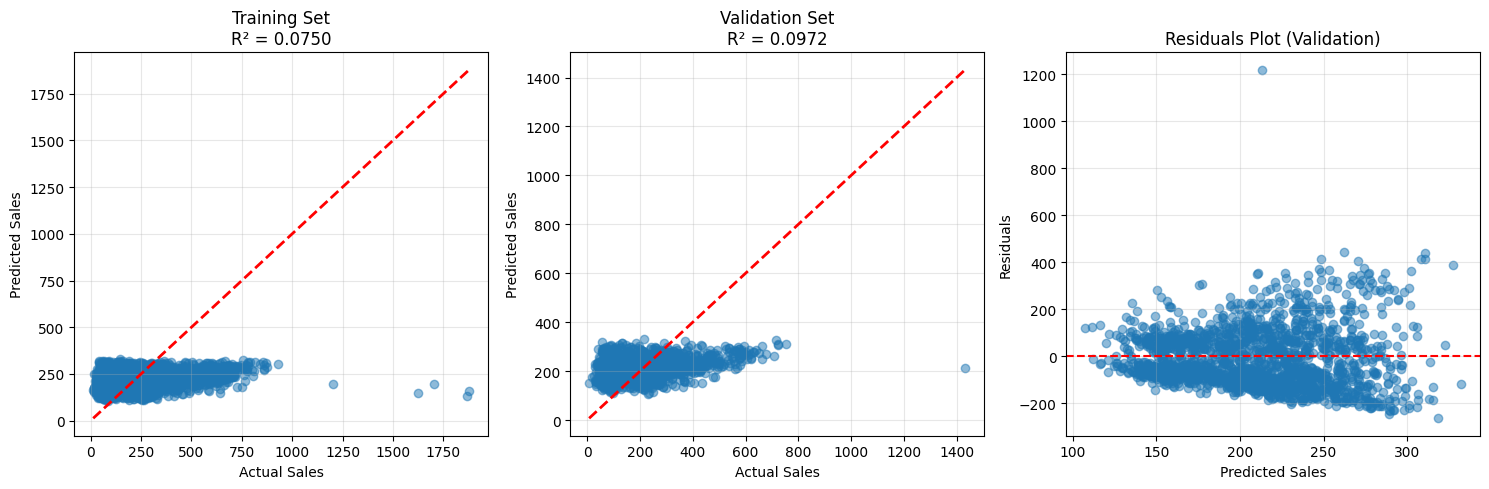

📈 Visualizations complete!


In [9]:
# Visualize predictions vs actual values
plt.figure(figsize=(15, 5))

# Training set
plt.subplot(1, 3, 1)
plt.scatter(y_train, y_train_pred, alpha=0.5)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title(f'Training Set\nR² = {train_r2:.4f}')
plt.grid(True, alpha=0.3)

# Validation set
plt.subplot(1, 3, 2)
plt.scatter(y_val, y_val_pred, alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title(f'Validation Set\nR² = {val_r2:.4f}')
plt.grid(True, alpha=0.3)

# Residuals plot
plt.subplot(1, 3, 3)
residuals = y_val - y_val_pred
plt.scatter(y_val_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.title('Residuals Plot (Validation)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📈 Visualizations complete!")

## Test Set Predictions

Now let's make predictions on the test set for Kaggle submission.

In [10]:
# Make predictions on test set
print("Making predictions on test set...")
test_predictions = linear_model.predict(X_test)

# Create submission file
submission_df = test_processed[['id']].copy()
submission_df['umsatz'] = test_predictions

# Ensure no negative predictions (sales can't be negative)
submission_df['umsatz'] = np.maximum(submission_df['umsatz'], 0)

print(f"Test predictions generated for {len(submission_df)} samples")
print(f"Prediction range: {submission_df['umsatz'].min():.2f} to {submission_df['umsatz'].max():.2f}")

# Display sample predictions
print("\nSample predictions:")
print(submission_df.head(10))

# Save submission file
submission_filename = 'simple_linear_model_submission.csv'
submission_df.to_csv(submission_filename, index=False)
print(f"\n✅ Submission file saved as '{submission_filename}'")

Making predictions on test set...
Test predictions generated for 1830 samples
Prediction range: 114.72 to 326.95

Sample predictions:
          id      umsatz
0  1808011.0  256.517310
1  1808012.0  251.812315
2  1808013.0  247.107321
3  1808015.0  237.697333
4  1808014.0  242.402327
5  1808022.0  262.962012
6  1808023.0  258.257018
7  1808024.0  253.552024
8  1808025.0  248.847030
9  1808021.0  267.667006

✅ Submission file saved as 'simple_linear_model_submission.csv'


## Summary

### Simple Linear Model Results

**Model Equation:**
```
umsatz = β₀ + β₁ × Temperatur + β₂ × Warengruppe + β₃ × is_weekend + β₄ × month + ε
```

**Next Steps:**
1. Upload the `simple_linear_model_submission.csv` file to Kaggle
2. Evaluate the performance score
3. Use this baseline to compare with more complex models

**Model Characteristics:**
- Simple interpretable model
- Uses basic features: temperature, product group, weekend indicator, and month
- Good baseline for comparison with more complex models